# Corridas de Rosenbrock con descenso por gradiente

Este notebook ejecuta corridas de la funcion de Rosenbrock en 2D y luego en 3D, guarda los resultados por separado y genera plots para inspeccionar el comportamiento del metodo en ambos casos.

In [17]:
import csv
import json
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

from funciones_gradientes import (
    get_initial_position,
    rosenbrock_gradient,
    run_gradient_descent,
)
from funciones_objetivo import rosenbrock

## Configuracion

Cambia `N_CORRIDAS_LISTA` si quieres usar otros tamanos de corrida. El notebook corre automaticamente `2D` y `3D` para cada valor de `n`.

In [18]:
N_CORRIDAS_LISTA = [100, 500, 1000]
DIMENSIONES = [2, 3]
LIMITS = (-2.048, 2.048)
RATE = 1e-4
MAX_ITERATIONS = 1000
TOLERANCE = 1e-6
SEED = 42

if any(d not in (2, 3) for d in DIMENSIONES):
    raise ValueError("DIMENSIONES solo puede contener 2 y/o 3.")

if any(n <= 0 for n in N_CORRIDAS_LISTA):
    raise ValueError("Todos los valores de N_CORRIDAS_LISTA deben ser positivos.")

In [19]:
def contar_evaluaciones(resultado: dict) -> int:
    """Cuenta evaluaciones de la funcion objetivo hechas durante la corrida."""
    return len(resultado["function_values"]) + 1


def ejecutar_corridas(dimension: int, n_corridas: int) -> list[dict]:
    """Ejecuta las corridas de Rosenbrock en la dimension indicada."""
    resultados = []

    for corrida in range(1, n_corridas + 1):
        posicion_inicial = get_initial_position(dimension, limits=LIMITS)
        resultado = run_gradient_descent(
            initial_position=posicion_inicial,
            function=rosenbrock,
            gradient_function=rosenbrock_gradient,
            rate=RATE,
            max_iterations=MAX_ITERATIONS,
            tolerance=TOLERANCE,
        )

        resultados.append(
            {
                "corrida": corrida,
                "dimension": dimension,
                "posicion_inicial": resultado["initial_position"].tolist(),
                "posicion_final": resultado["final_position"].tolist(),
                "valor_final": float(resultado["final_value"]),
                "iteraciones": int(resultado["iterations"]),
                "evaluaciones": contar_evaluaciones(resultado),
            }
        )

    return resultados


def guardar_resultados(resultados: list[dict], dimension: int, n_corridas: int) -> tuple[Path, Path]:
    """Guarda los resultados en JSON y CSV usando nombres dinamicos."""
    directorio_salida = Path("datos")
    directorio_salida.mkdir(exist_ok=True)

    base_name = f"rosenbrock_{dimension}d_n{n_corridas}"
    json_path = directorio_salida / f"{base_name}.json"
    csv_path = directorio_salida / f"{base_name}.csv"

    with json_path.open("w", encoding="utf-8") as json_file:
        json.dump(resultados, json_file, indent=2)

    with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=[
                "corrida",
                "dimension",
                "posicion_inicial",
                "posicion_final",
                "valor_final",
                "iteraciones",
                "evaluaciones",
            ],
        )
        writer.writeheader()
        writer.writerows(resultados)

    return json_path, csv_path

In [20]:
np.random.seed(SEED)
resultados_por_dimension = {}

for dimension in DIMENSIONES:
    resultados_por_dimension[dimension] = {}

    for n_corridas in N_CORRIDAS_LISTA:
        resultados = ejecutar_corridas(dimension, n_corridas)
        json_path, csv_path = guardar_resultados(resultados, dimension, n_corridas)
        resultados_por_dimension[dimension][n_corridas] = {
            "resultados": resultados,
            "json_path": json_path,
            "csv_path": csv_path,
        }

        print(f"Corridas ejecutadas: {len(resultados)}")
        print(f"Dimension: {dimension}D")
        print(f"n = {n_corridas}")
        print(f"JSON guardado en: {json_path}")
        print(f"CSV guardado en: {csv_path}")
        print("-" * 50)

Corridas ejecutadas: 100
Dimension: 2D
JSON guardado en: datos\rosenbrock_2d_n100.json
CSV guardado en: datos\rosenbrock_2d_n100.csv
--------------------------------------------------
Corridas ejecutadas: 100
Dimension: 3D
JSON guardado en: datos\rosenbrock_3d_n100.json
CSV guardado en: datos\rosenbrock_3d_n100.csv
--------------------------------------------------


In [21]:
for dimension in DIMENSIONES:
    for n_corridas in N_CORRIDAS_LISTA:
        resultados = resultados_por_dimension[dimension][n_corridas]["resultados"]
        valores_finales = np.array([fila["valor_final"] for fila in resultados], dtype=float)
        evaluaciones = np.array([fila["evaluaciones"] for fila in resultados], dtype=int)
        iteraciones = np.array([fila["iteraciones"] for fila in resultados], dtype=int)

        print(f"Resumen Rosenbrock {dimension}D - n={n_corridas}")
        print(f"Mejor valor final: {valores_finales.min():.8f}")
        print(f"Peor valor final: {valores_finales.max():.8f}")
        print(f"Promedio valor final: {valores_finales.mean():.8f}")
        print(f"Promedio evaluaciones: {evaluaciones.mean():.2f}")
        print(f"Promedio iteraciones: {iteraciones.mean():.2f}")
        print("-" * 50)

Resumen Rosenbrock 2D - n=100
Mejor valor final: 0.00161713
Peor valor final: 5.71175791
Promedio valor final: 1.35599782
Promedio evaluaciones: 1002.00
Promedio iteraciones: 1000.00
--------------------------------------------------
Resumen Rosenbrock 3D - n=100
Mejor valor final: 0.01260209
Peor valor final: 5.04597278
Promedio valor final: 1.78217035
Promedio evaluaciones: 1002.00
Promedio iteraciones: 1000.00
--------------------------------------------------


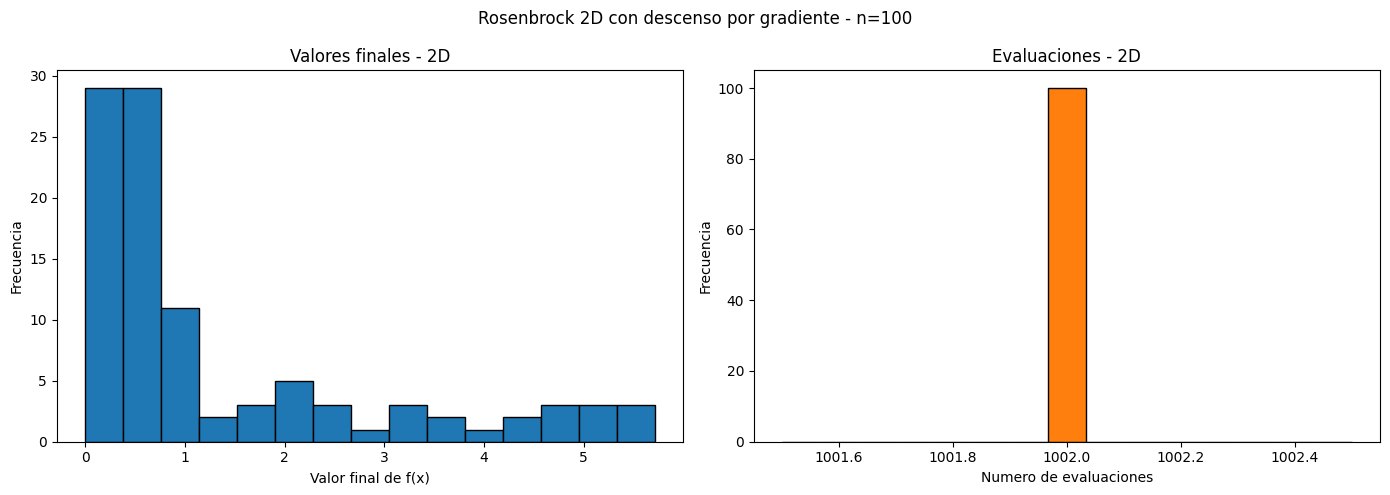

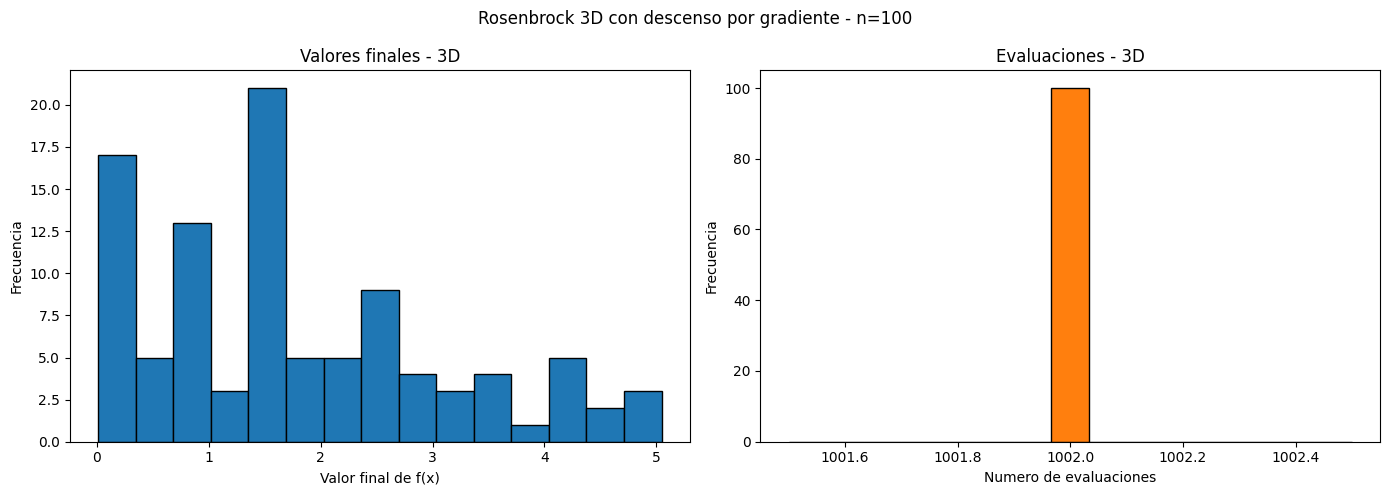

In [22]:
for dimension in DIMENSIONES:
    fig, axes = plt.subplots(2, len(N_CORRIDAS_LISTA), figsize=(5 * len(N_CORRIDAS_LISTA), 8))

    for idx, n_corridas in enumerate(N_CORRIDAS_LISTA):
        resultados = resultados_por_dimension[dimension][n_corridas]["resultados"]
        valores_finales = np.array([fila["valor_final"] for fila in resultados], dtype=float)
        evaluaciones = np.array([fila["evaluaciones"] for fila in resultados], dtype=int)

        axes[0, idx].hist(valores_finales, bins=15, color="#1f77b4", edgecolor="black")
        axes[0, idx].set_title(f"Valores finales - n={n_corridas}")
        axes[0, idx].set_xlabel("Valor final de f(x)")
        axes[0, idx].set_ylabel("Frecuencia")

        axes[1, idx].hist(evaluaciones, bins=15, color="#ff7f0e", edgecolor="black")
        axes[1, idx].set_title(f"Evaluaciones - n={n_corridas}")
        axes[1, idx].set_xlabel("Numero de evaluaciones")
        axes[1, idx].set_ylabel("Frecuencia")

    plt.suptitle(f"Rosenbrock {dimension}D - comparacion de n=100, 500 y 1000")
    plt.tight_layout()
    plt.show()

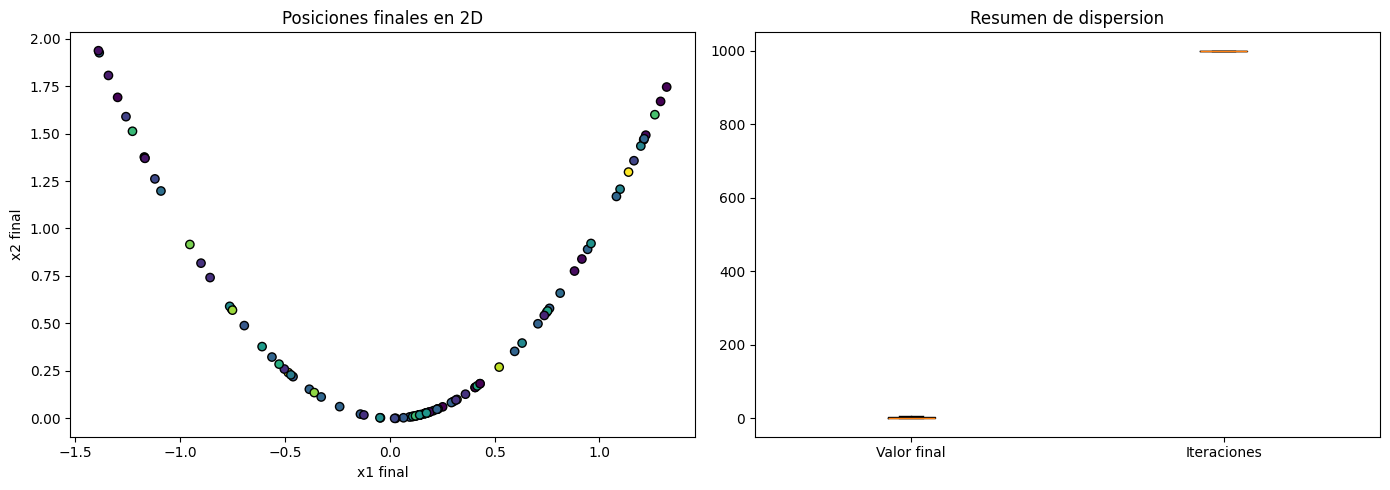

In [23]:
# Celda antigua deshabilitada.
# Los graficos vigentes se generan en la celda posterior usando
# resultados_por_dimension[dimension][n_corridas] para evitar mezclar
# arreglos de corridas distintas (por ejemplo n=100 con n=1000).
pass

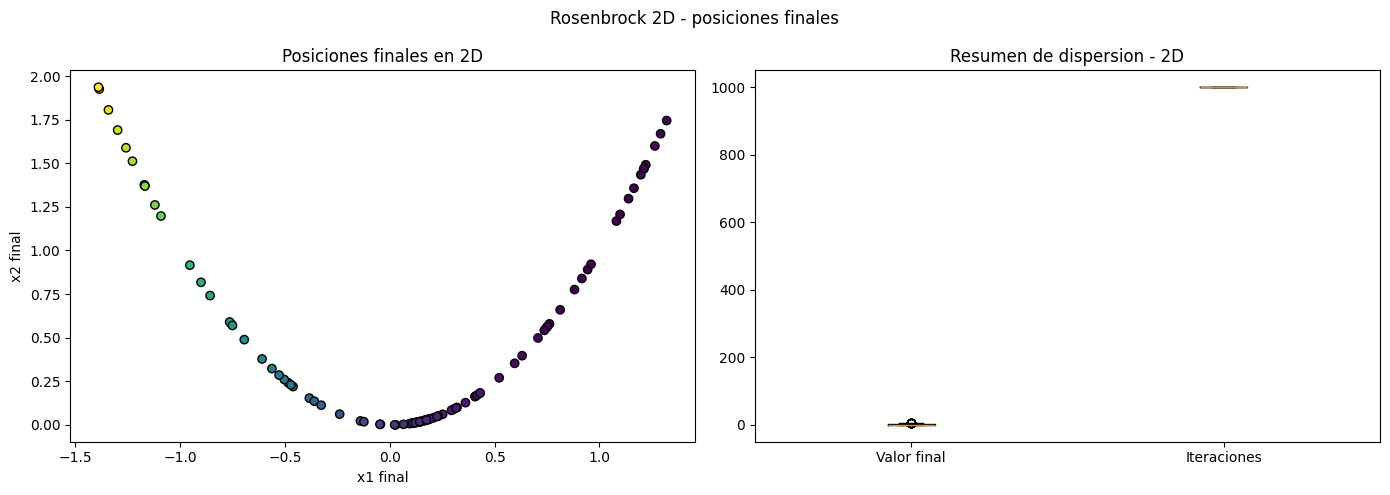

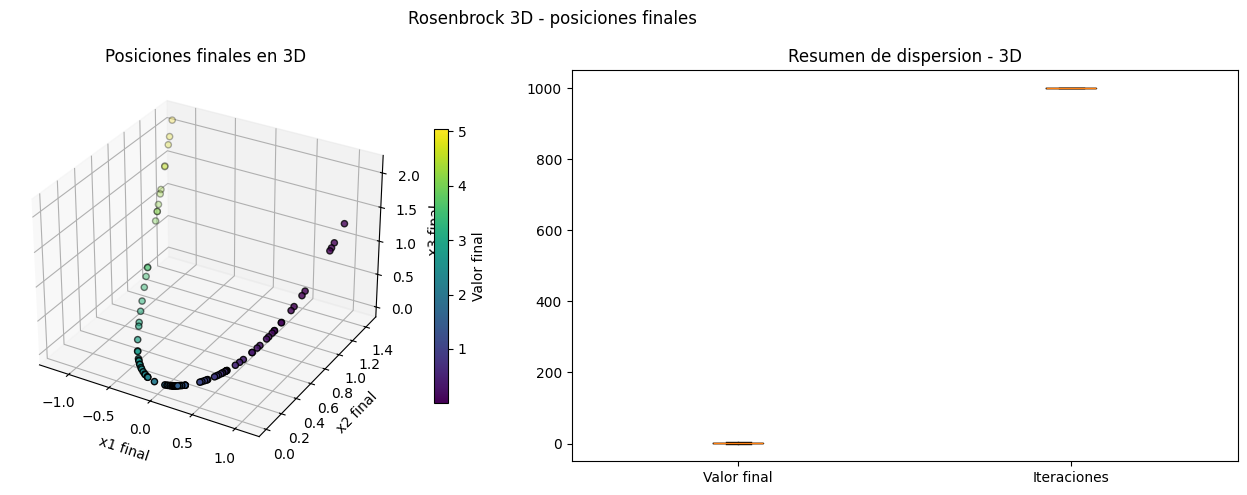

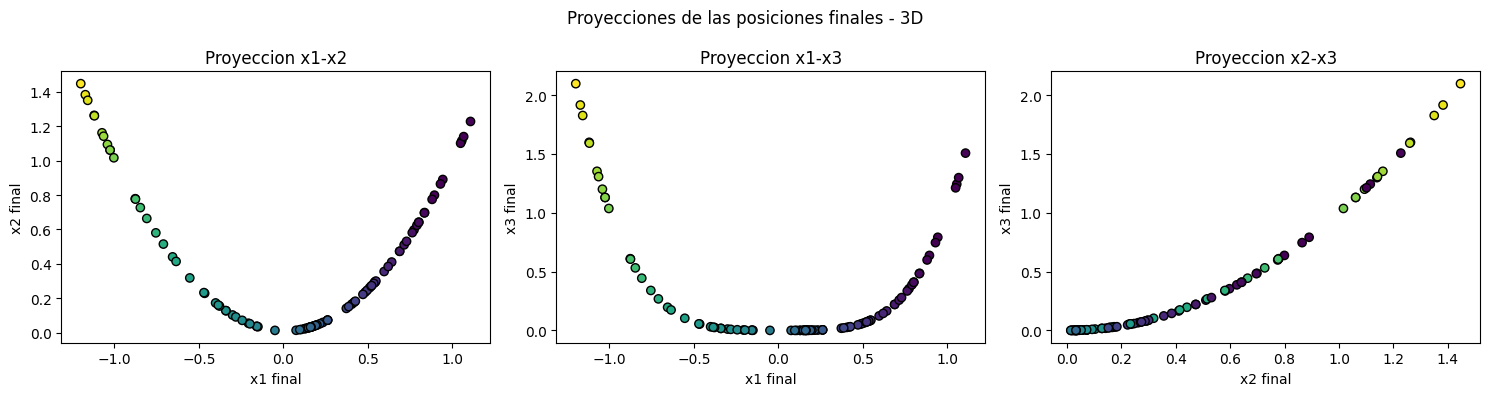

In [24]:
for dimension in DIMENSIONES:
    n_corridas = N_CORRIDAS_LISTA[-1]
    resultados = resultados_por_dimension[dimension][n_corridas]["resultados"]
    valores_finales = np.array([fila["valor_final"] for fila in resultados], dtype=float)
    iteraciones = np.array([fila["iteraciones"] for fila in resultados], dtype=int)
    posiciones_finales = np.array([fila["posicion_final"] for fila in resultados], dtype=float)

    if dimension == 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].scatter(
            posiciones_finales[:, 0],
            posiciones_finales[:, 1],
            c=valores_finales,
            cmap="viridis",
            edgecolors="black",
        )
        axes[0].set_title("Posiciones finales en 2D")
        axes[0].set_xlabel("x1 final")
        axes[0].set_ylabel("x2 final")

        axes[1].boxplot([valores_finales, iteraciones], tick_labels=["Valor final", "Iteraciones"])
        axes[1].set_title("Resumen de dispersion - 2D")

        plt.suptitle(f"Rosenbrock {dimension}D - posiciones finales (n={n_corridas})")
        plt.tight_layout()
        plt.show()

    if dimension == 3:
        fig = plt.figure(figsize=(14, 5))

        ax1 = fig.add_subplot(1, 2, 1, projection="3d")
        scatter = ax1.scatter(
            posiciones_finales[:, 0],
            posiciones_finales[:, 1],
            posiciones_finales[:, 2],
            c=valores_finales,
            cmap="viridis",
            edgecolors="black",
        )
        ax1.set_title("Posiciones finales en 3D")
        ax1.set_xlabel("x1 final")
        ax1.set_ylabel("x2 final")
        ax1.set_zlabel("x3 final")
        fig.colorbar(scatter, ax=ax1, shrink=0.7, label="Valor final")

        ax2 = fig.add_subplot(1, 2, 2)
        ax2.boxplot([valores_finales, iteraciones], tick_labels=["Valor final", "Iteraciones"])
        ax2.set_title("Resumen de dispersion - 3D")

        plt.suptitle(f"Rosenbrock {dimension}D - posiciones finales (n={n_corridas})")
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].scatter(posiciones_finales[:, 0], posiciones_finales[:, 1], c=valores_finales, cmap="viridis", edgecolors="black")
        axes[0].set_title("Proyeccion x1-x2")
        axes[0].set_xlabel("x1 final")
        axes[0].set_ylabel("x2 final")

        axes[1].scatter(posiciones_finales[:, 0], posiciones_finales[:, 2], c=valores_finales, cmap="viridis", edgecolors="black")
        axes[1].set_title("Proyeccion x1-x3")
        axes[1].set_xlabel("x1 final")
        axes[1].set_ylabel("x3 final")

        axes[2].scatter(posiciones_finales[:, 1], posiciones_finales[:, 2], c=valores_finales, cmap="viridis", edgecolors="black")
        axes[2].set_title("Proyeccion x2-x3")
        axes[2].set_xlabel("x2 final")
        axes[2].set_ylabel("x3 final")

        fig.suptitle("Proyecciones de las posiciones finales - 3D")
        fig.tight_layout()
        plt.show()